### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

top_10_alcol = df.nlargest(10, "total_litres_of_pure_alcohol")[["country", "total_litres_of_pure_alcohol"]]
media_consumi = df[["beer_servings", "wine_servings", "spirit_servings"]].mean()
df["alcohol_index"] = (df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3
paese_max_index = df.loc[df["alcohol_index"].idxmax(), ["country", "alcohol_index"]]
paesi_birra_oltre_100 = df[df["beer_servings"] > 100][["country", "beer_servings"]]
wine_ordinato = df.sort_values("country")[["country", "wine_servings"]]

print("Top 10 paesi per consumo totale di alcol:")
display(top_10_alcol)
print()
print("Media consumo birra, vino e distillati:")
print(media_consumi)
print()
print("Paese con alcohol_index massimo:")
display(paese_max_index.to_frame().T)
print()
print("Paesi con più di 100 birre all'anno:")
display(paesi_birra_oltre_100)

plt.figure(figsize=(10, 5))
plt.bar(top_10_alcol["country"], top_10_alcol["total_litres_of_pure_alcohol"], color="skyblue")
plt.title("Top 10 paesi per consumo totale di alcol")
plt.xlabel("Paese")
plt.ylabel("Litri di alcol puro")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(wine_ordinato["country"], wine_ordinato["wine_servings"], color="darkred")
plt.title("Wine servings ordinato per paese")
plt.xlabel("Paese")
plt.ylabel("Wine servings")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

df_pulito = df.dropna(subset=["job_country", "salary_year_avg", "job_title_short"])

analisi_paese = df_pulito.groupby("job_country").agg(
    stipendio_medio_annuale=("salary_year_avg", "mean"),
    numero_offerte=("salary_year_avg", "size"),
    stipendio_minimo=("salary_year_avg", "min"),
    stipendio_massimo=("salary_year_avg", "max")
).sort_values("stipendio_medio_annuale", ascending=False)

stipendio_per_ruolo = df_pulito.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=False)

print("Analisi stipendi per paese:")
display(analisi_paese)

plt.figure(figsize=(10, 6))
stipendio_per_ruolo.sort_values().plot(kind="barh", color="seagreen")
plt.title("Stipendio medio annuale per job_title_short")
plt.xlabel("Salary year average")
plt.ylabel("Job title short")
plt.tight_layout()
plt.show()


### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

Matplotlib is building the font cache; this may take a moment.


Analisi vendite per giorno:


,conto_medio,numero_osservazioni,conto_minimo,conto_massimo
day,,,,
Sun,21.410000,76,7.25,48.17
Sat,20.441379,87,3.07,50.81
Thur,17.682742,62,7.51,43.11
Fri,17.151579,19,5.75,40.17



Giorno con conto medio più alto: Sun


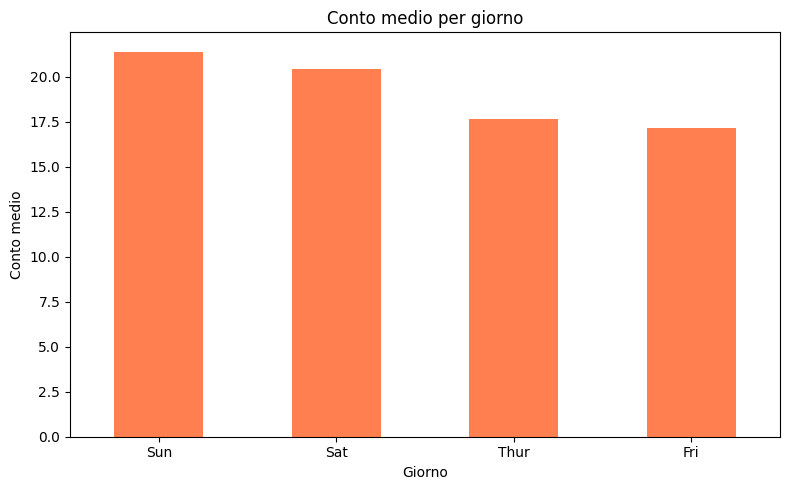

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df["conto_per_persona"] = df["total_bill"] / df["size"]

analisi_giorno = df.groupby("day").agg(
    conto_medio=("total_bill", "mean"),
    numero_osservazioni=("total_bill", "size"),
    conto_minimo=("total_bill", "min"),
    conto_massimo=("total_bill", "max")
).sort_values("conto_medio", ascending=False)

giorno_conto_medio_massimo = analisi_giorno["conto_medio"].idxmax()

print("Analisi vendite per giorno:")
display(analisi_giorno)
print()
print("Giorno con conto medio più alto:", giorno_conto_medio_massimo)

plt.figure(figsize=(8, 5))
analisi_giorno["conto_medio"].plot(kind="bar", color="coral")
plt.title("Conto medio per giorno")
plt.xlabel("Giorno")
plt.ylabel("Conto medio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
